--- 1 y 2. Primeras filas del dataset original ---
   Tiempo (s)  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
0           0       43.708611          9.256646         23.925585
1           1       95.564288         27.095047         23.704682
2           2       75.879455         43.647292         33.593819
3           3       63.879264         36.611244         23.743193
4           4       24.041678         40.328057         24.079246

--- 3. Dataset limpio (sin nulos y sin velocidades negativas) ---
       Tiempo (s)  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
count  913.000000      913.000000        913.000000        913.000000
mean   498.173056       54.079714         25.324031         27.538971
std    289.608036       26.423786         14.623216          4.377366
min      0.000000       10.416882          0.160913         20.000175
25%    248.000000       30.591835         12.060073         23.904303
50%    498.000000       55.136467         25.988697         27.546

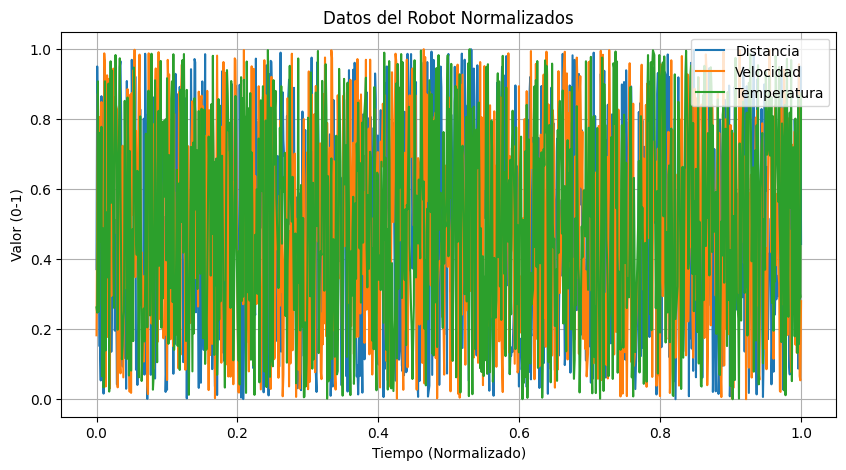

In [1]:
#Actividad 5: Procesamiento de conjuntos de datos en Python
#Reyli Isaac Morales Zarazua 2007856
#Ernesto Gerardo Loera Vega 2101664
#Arturo Gabriel Sandoval Villarreal 2100680
#Jesus Alexander Guzmán Eguia 2052987
#Edgar Abraham Padilla Quiroz 2121425
#HORA CLASE: V6
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Cargar el dataset con pandas (usando la URL del repositorio)
url = "https://raw.githubusercontent.com/dilp90/InteligenciaArtificial_y_RedesNeuronales_UANL_FIME/main/MachineLearning/Datasets/robot_sensors.csv"
df = pd.read_csv(url)

# 2. Mostrar primeras filas del dataset
print("--- 1 y 2. Primeras filas del dataset original ---")
print(df.head())

# 3. Limpiar los datos
# a. Eliminar filas con valores nulos
df = df.dropna()

# b. Filtrar valores atípicos (velocidad negativa)
df = df[df['Velocidad (cm/s)'] >= 0]

print("\n--- 3. Dataset limpio (sin nulos y sin velocidades negativas) ---")
print(df.describe())

# 4. Normalizar los datos numéricos con Min-Max Scaling
scaler = MinMaxScaler()
# Seleccionamos las columnas a normalizar
columnas = ['Tiempo (s)', 'Distancia (cm)', 'Velocidad (cm/s)', 'Temperatura (°C)']
df_norm = df.copy()
df_norm[columnas] = scaler.fit_transform(df[columnas])

print("\n--- 4. Primeras filas de datos normalizados (escala 0-1) ---")
print(df_norm.head())

# 5. Visualizar los datos normalizados usando matplotlib
plt.figure(figsize=(10, 5))
plt.plot(df_norm['Tiempo (s)'], df_norm['Distancia (cm)'], label='Distancia')
plt.plot(df_norm['Tiempo (s)'], df_norm['Velocidad (cm/s)'], label='Velocidad')
plt.plot(df_norm['Tiempo (s)'], df_norm['Temperatura (°C)'], label='Temperatura')

plt.title('Datos del Robot Normalizados')
plt.xlabel('Tiempo (Normalizado)')
plt.ylabel('Valor (0-1)')
plt.legend()
plt.grid(True)
plt.show()